# Aprendizagem de Máquina - Web Academy

## Prática de Agrupamento (Clustering)

### 1.1. O Problema de Negócio: Por Que Segmentar Clientes?

No universo do e-commerce e do varejo digital, uma verdade fundamental prevalece: nem todos os clientes são iguais. Estratégias de marketing que adotam uma abordagem de "tamanho único" frequentemente se mostram ineficientes e dispendiosas. A segmentação de clientes surge como a solução para este desafio, permitindo que as empresas dividam sua base de consumidores em grupos homogêneos com características e comportamentos semelhantes. Esta prática possibilita a personalização de campanhas, a otimização do retorno sobre o investimento (ROI) em marketing e, crucialmente, o aprimoramento da retenção de clientes valiosos.

O objetivo central desta aula é eminentemente prático: transformar um vasto arquivo de dados transacionais, contendo mais de um milhão de registros de um e-commerce, em um conjunto conciso e acionável de segmentos de clientes. Ao final, teremos de 3 a 5 grupos claramente definidos — como "Clientes Campeões", "Clientes em Risco" e "Novos Clientes" — que podem ser imediatamente utilizados por equipes de marketing para criar campanhas direcionadas e eficazes. Este processo demonstra o poder do machine learning em traduzir dados brutos em inteligência de negócio.

### 1.2. Apresentando o Modelo RFM: A Lógica por Trás dos Dados

Para realizar a segmentação, será utilizada uma técnica consagrada no marketing chamada Análise RFM. RFM é um acrônimo para **Recência, Frequência e Valor Monetário**. Mais do que um conjunto de métricas estatísticas, o RFM é um modelo de análise de comportamento do cliente, projetado para quantificar o valor e o engajamento de cada consumidor com base em seu histórico de transações.

A intuição por trás de cada uma das três métricas é direta e poderosa:

* **Recência (R):** "Quando foi a última vez que o cliente realizou uma compra?" A lógica é que clientes que compraram mais recentemente têm a marca mais "fresca" em suas mentes e, portanto, são mais propensos a responder a novas ofertas e a realizar uma nova compra. Uma recência baixa (poucos dias desde a última compra) é um indicador positivo.
* **Frequência (F):** "Com que frequência o cliente compra?" Clientes que realizam compras repetidas demonstram um nível mais alto de lealdade e engajamento com a marca. Uma frequência alta é um forte sinal de um cliente satisfeito e retido.
* **Valor Monetário (M):** "Quanto dinheiro o cliente gasta no total?" Esta métrica identifica os clientes que mais contribuem para a receita do negócio. Clientes com um alto valor monetário são, por definição, extremamente valiosos.

A análise RFM fundamenta-se na premissa de que o comportamento de compra passado é o melhor preditor do comportamento futuro. É uma aplicação direta do Princípio de Pareto (a regra 80/20), que, no contexto de negócios, sugere que aproximadamente 80% da receita é gerada por 20% dos clientes. O modelo RFM fornece um framework quantitativo para identificar precisamente quem são esses 20% de clientes vitais, bem como para diagnosticar outros grupos, como aqueles que estão prestes a serem perdidos (churn). Portanto, a análise RFM não é apenas um exercício de análise de dados; é uma ferramenta estratégica de diagnóstico de negócios.

### 1.3. Nosso Plano de Ação: O Roteiro do Projeto

Para atingir nosso objetivo, seguiremos um roteiro estruturado que reflete um projeto de ciência de dados do mundo real. Este plano de ação nos guiará desde os dados brutos até a interpretação final dos segmentos de clientes.

O fluxo de trabalho da aula será o seguinte:

1.  **Dados Brutos:** Iniciaremos carregando o dataset transacional de e-commerce.
2.  **Limpeza e Preparação:** Abordaremos os desafios comuns de dados do mundo real, como valores ausentes, cancelamentos e registros inválidos.
3.  **Engenharia de Features:** A etapa crucial onde calcularemos as métricas de Recência, Frequência e Valor Monetário para cada cliente.
4.  **Pré-processamento:** Normalizaremos os dados, um passo essencial para garantir que nosso modelo de machine learning funcione corretamente.
5.  **Modelagem:** Aplicaremos o algoritmo de clusterização K-Means para agrupar os clientes com base em suas métricas RFM.
6.  **Interpretação:** O passo final e mais importante, onde transformaremos os clusters matemáticos em "personas" de clientes compreensíveis e acionáveis.
7.  **Desafio Final:** Consolidaremos o aprendizado aplicando todo o processo em um novo e mais complexo dataset.

## Seção 2: Preparando o Terreno: Carregamento e Limpeza dos Dados

### 2.1. Conhecendo o Dataset "Online Retail II"

O ponto de partida de nosso projeto é o dataset "Online Retail II", disponibilizado pelo UCI Machine Learning Repository. Este conjunto de dados é valioso por conter transações reais de uma empresa de varejo online sediada no Reino Unido, cobrindo um período de dois anos, de dezembro de 2009 a dezembro de 2011. A empresa vende principalmente artigos para presente, e uma parcela significativa de seus clientes são atacadistas, o que explica a presença de transações com grandes quantidades de itens.

Primeiramente, vamos importar as bibliotecas e carregar os dados para realizar uma análise inicial e entender sua estrutura.

In [3]:
# Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações para melhor visualização
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 500)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Carregando o dataset
# O dataset original vem em duas partes (dois arquivos.xlsx). Vamos carregá-los e concatená-los.
# Para executar este notebook, você precisará baixar os arquivos do repositório UCI e colocá-los no mesmo diretório.
# Link: https://archive.ics.uci.edu/dataset/502/online+retail+ii
try:
    df_2009_2010 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2009-2010')
    df_2010_2011 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')
    df = pd.concat([df_2009_2010, df_2010_2011], ignore_index=True)
except FileNotFoundError:
    print("Arquivo 'online_retail_II.xlsx' não encontrado. Crie um dataframe de exemplo para continuar.")
    # Criando um dataframe de exemplo caso o arquivo não seja encontrado
    data_exemplo = {
        'Invoice': ['536365', '536365', '536366', 'C536379', '536381', '536381'],
        'StockCode': ['85123A', '71053', '22633', 'D', '22423', '85099B'],
        'Description': ['CREAM CUPID HEARTS COAT HANGER', 'WHITE METAL LANTERN', 'HAND WARMER UNION JACK', 'Discount', 'REGENCY CAKESTAND 3 TIER', 'JUMBO BAG RED RETROSPOT'],
        'Quantity': [6, 6, 2, -1, 8, 2],
        'InvoiceDate': [dt.datetime(2010, 12, 1, 8, 26), dt.datetime(2010, 12, 1, 8, 26), dt.datetime(2010, 12, 1, 8, 28), dt.datetime(2010, 12, 1, 9, 41), dt.datetime(2010, 12, 1, 9, 41), dt.datetime(2010, 12, 1, 9, 41)],
        'Price': [2.75, 3.39, 1.85, 27.50, 12.75, 1.95],
        'Customer ID': [17850.0, 17850.0, 17850.0, 14527.0, 15311.0, 15311.0],
        'Country': ['United Kingdom', 'United Kingdom', 'United Kingdom', 'United Kingdom', 'United Kingdom', 'United Kingdom']
    }
    df = pd.DataFrame(data_exemplo)

# Exibindo as primeiras linhas para uma inspeção visual
print("Primeiras 5 linhas do dataset:")
print(df.head())
print("\nInformações gerais do dataset:")
df.info()
print("\nEstatísticas descritivas:")
print(df.describe().T)

Arquivo 'online_retail_II.xlsx' não encontrado. Crie um dataframe de exemplo para continuar.
Primeiras 5 linhas do dataset:
   Invoice StockCode                     Description  Quantity         InvoiceDate  Price  Customer ID         Country
0   536365    85123A  CREAM CUPID HEARTS COAT HANGER         6 2010-12-01 08:26:00  2.750    17850.000  United Kingdom
1   536365     71053             WHITE METAL LANTERN         6 2010-12-01 08:26:00  3.390    17850.000  United Kingdom
2   536366     22633          HAND WARMER UNION JACK         2 2010-12-01 08:28:00  1.850    17850.000  United Kingdom
3  C536379         D                        Discount        -1 2010-12-01 09:41:00 27.500    14527.000  United Kingdom
4   536381     22423        REGENCY CAKESTAND 3 TIER         8 2010-12-01 09:41:00 12.750    15311.000  United Kingdom

Informações gerais do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 8 columns):
 #   Column       Non-Null Cou

A análise inicial revela o seguinte dicionário de dados:

* `Invoice`: Número da fatura. Se começar com a letra 'C', indica um cancelamento.
* `StockCode`: Código do produto.
* `Description`: Nome do produto.
* `Quantity`: Quantidade de itens por transação. Pode ser negativa para devoluções.
* `InvoiceDate`: Data e hora da transação.
* `Price`: Preço unitário em libras esterlinas (£).
* `Customer ID`: Identificador único do cliente. Essencial para nossa análise.
* `Country`: País de residência do cliente.

### 2.2. A Realidade dos Dados Brutos: O Processo de Limpeza (EDA)

A limpeza de dados é frequentemente vista como uma etapa preliminar, mas na prática, é a primeira e mais crítica fase da Análise Exploratória de Dados (EDA). Cada decisão de limpeza reflete uma regra de negócio e impacta diretamente a qualidade do resultado final. O objetivo é calcular o valor de um cliente; transações canceladas, produtos devolvidos ou compras de clientes não identificados não agregam valor e não podem ser usados para segmentação. Portanto, a limpeza define o escopo do que consideramos um cliente analisável.

Seguiremos os seguintes passos práticos para a limpeza:

In [4]:
print(f"Formato original do dataframe: {df.shape}")

# 1. Tratando Valores Ausentes
print("\nVerificando valores nulos por coluna:")
print(df.isnull().sum())

# A coluna `Customer ID` é a chave. Registros sem `Customer ID` são inúteis para a segmentação.
df_cleaned = df.dropna(subset=['Customer ID'])
print(f"\nFormato após remover nulos em Customer ID: {df_cleaned.shape}")

# 2. Removendo Cancelamentos
# Transações cujo `Invoice` começa com 'C' são cancelamentos.
df_cleaned['Invoice'] = df_cleaned['Invoice'].astype(str)
df_cleaned = df_cleaned[~df_cleaned['Invoice'].str.contains('C', na=False)]
print(f"Formato após remover cancelamentos: {df_cleaned.shape}")

# 3. Filtrando Quantidades e Preços Inválidos
# Uma `Quantity` negativa indica uma devolução. Um `Price` igual a zero não representa uma compra válida.
df_cleaned = df_cleaned[(df_cleaned['Quantity'] > 0) & (df_cleaned['Price'] > 0)]
print(f"Formato após remover quantidades e preços inválidos: {df_cleaned.shape}")

# 4. Verificando Duplicatas
print(f"\nNúmero de linhas duplicadas: {df_cleaned.duplicated().sum()}")
df_cleaned.drop_duplicates(inplace=True)
print(f"Formato final após limpeza: {df_cleaned.shape}")

Formato original do dataframe: (6, 8)

Verificando valores nulos por coluna:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

Formato após remover nulos em Customer ID: (6, 8)
Formato após remover cancelamentos: (5, 8)
Formato após remover quantidades e preços inválidos: (5, 8)

Número de linhas duplicadas: 0
Formato final após limpeza: (5, 8)


### Exercício Prático 1: Inspetor de Dados

Dado o pequeno dataframe de amostra abaixo, escreva o código Python para limpá-lo completamente, seguindo as regras discutidas: remover nulos em `CustomerID`, remover cancelamentos, remover quantidades negativas e remover duplicatas. Imprima o formato (`.shape`) do dataframe antes e depois da limpeza.

In [6]:
# Dataframe de amostra para o exercício
data_exercicio = {
    'Invoice': ['536365', 'C536368', '536369', '536370', '536370', '536371'],
    'Quantity': [6, -1, 3, 20, 20, 8],
    'Price': [2.55, 4.25, 3.75, 7.85, 7.85, 2.08],
    'CustomerID': [17850.0, 13047.0, 13047.0, 12583.0, 12583.0, np.nan]
}
df_exercicio = pd.DataFrame(data_exercicio)

print(f"Formato inicial do df_exercicio: {df_exercicio.shape}")

# --- SEU CÓDIGO DE LIMPEZA AQUI ---

# 1. Remover nulos em CustomerID

# 2. Remover cancelamentos


# 3. Remover quantidades negativas

# 4. Remover duplicatas


print(f"Formato final do df_exercicio_limpo: {df_exercicio_limpo.shape}")
print("\nDataframe limpo:")
print(df_exercicio_limpo)

Formato inicial do df_exercicio: (6, 4)


NameError: name 'df_exercicio_limpo' is not defined

## Seção 3: Engenharia de Features: Construindo as Métricas RFM

Com os dados limpos, o próximo passo é transformá-los. Atualmente, temos um registro de transações individuais. Precisamos agregar esses dados para criar um perfil para cada cliente, e esse perfil será composto pelas métricas RFM. Este processo é conhecido como **engenharia de features**.

### 3.1. Criando a Base para o Cálculo: A Coluna `TotalPrice`

O Valor Monetário de cada transação não está explicitamente presente no dataset. É necessário calculá-lo multiplicando a quantidade de itens pelo seu preço unitário. Esta nova coluna, `TotalPrice`, será a base para o cálculo da métrica Monetária (M).

In [7]:
# Criando a coluna TotalPrice
df_cleaned['TotalPrice'] = df_cleaned['Quantity'] * df_cleaned['Price']
print("Coluna 'TotalPrice' criada. Exemplo:")
print(df_cleaned[['Quantity', 'Price', 'TotalPrice']].head())

Coluna 'TotalPrice' criada. Exemplo:
   Quantity  Price  TotalPrice
0         6  2.750      16.500
1         6  3.390      20.340
2         2  1.850       3.700
4         8 12.750     102.000
5         2  1.950       3.900


### 3.2. a 3.5. Calculando Recência, Frequência, Valor Monetário e Consolidando a Tabela RFM

Para calcular a recência, precisamos de um ponto de referência temporal. Uma prática comum é usar a data da transação mais recente em todo o dataset e adicionar um dia. Isso cria um "hoje" hipotético, a partir do qual medimos há quantos dias cada cliente fez sua última compra.

Podemos calcular as três métricas e consolidá-las em uma única operação usando o método `.agg()` do Pandas, o que é mais eficiente.

In [8]:
# Convertendo a coluna de data para o formato datetime
df_cleaned['InvoiceDate'] = pd.to_datetime(df_cleaned['InvoiceDate'])

# Definindo a data de referência (snapshot_date)
snapshot_date = df_cleaned['InvoiceDate'].max() + dt.timedelta(days=1)
print(f"Data de referência (Snapshot Date): {snapshot_date}")

# Calculando RFM em uma única etapa
rfm = df_cleaned.groupby('Customer ID').agg({
    'InvoiceDate': lambda date: (snapshot_date - date.max()).days, # Recência
    'Invoice': 'nunique',                                    # Frequência
    'TotalPrice': 'sum'                                        # Valor Monetário
})

# Renomeando as colunas
rfm.rename(columns={'InvoiceDate': 'Recency',
                    'Invoice': 'Frequency',
                    'TotalPrice': 'Monetary'}, inplace=True)

# Exibindo as primeiras linhas da tabela RFM final
print("\nTabela RFM final:")
print(rfm.head())

Data de referência (Snapshot Date): 2010-12-02 09:41:00

Tabela RFM final:
             Recency  Frequency  Monetary
Customer ID                              
15311.000          1          1   105.900
17850.000          1          2    40.540


Esta tabela é a materialização do vetor de características que descreve cada cliente. É a partir dela que o algoritmo de clusterização aprenderá os padrões de comportamento.

### Exercício Prático 2: Mestre da Frequência

Usando o dataframe limpo (`df_cleaned`), calcule a Frequência para os 5 clientes com os maiores `CustomerID`. Qual desses clientes realizou o maior número de compras?

In [ ]:
# --- SEU CÓDIGO AQUI ---

# Pegando os 5 maiores CustomerIDs

# Filtrando o dataframe para conter apenas esses clientes

# Calculando a frequência para eles


## Seção 4: A Importância da Escala: Normalizando os Dados com StandardScaler

### 4.1. Por que a Normalização é Crucial para o K-Means?

O algoritmo K-Means funciona medindo a distância entre os pontos de dados. Se aplicarmos o K-Means diretamente aos dados RFM, o algoritmo dará um peso desproporcional à métrica com a maior escala (`Monetary`), enviesando os clusters. A **normalização** (ou, mais precisamente, a **padronização**) resolve este problema colocando todas as features em uma "escala comum", garantindo que cada uma contribua de forma equitativa para o cálculo da distância.

### 4.2. Entendendo o StandardScaler

O `StandardScaler` do Scikit-learn transforma os dados de modo que cada feature tenha uma média ($\mu$) de 0 e um desvio padrão ($\sigma$) de 1. A fórmula aplicada a cada ponto de dado ($x$) é:

$$z = \frac{(x - \mu)}{\sigma}$$

O valor resultante, $z$, é chamado de *z-score*.

In [9]:
from sklearn.preprocessing import StandardScaler

# Instanciando o scaler
scaler = StandardScaler()

# Ajustando e transformando os dados
rfm_scaled = scaler.fit_transform(rfm)

# O resultado é um array NumPy. É útil convertê-lo de volta para um DataFrame para inspeção
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=rfm.columns, index=rfm.index)

print("Estatísticas descritivas após a padronização:")
print(rfm_scaled_df.describe().T)
# Note como a média (mean) está próxima de 0 e o desvio padrão (std) está próximo de 1.

Estatísticas descritivas após a padronização:
           count  mean   std    min    25%   50%   75%   max
Recency    2.000 0.000 0.000  0.000  0.000 0.000 0.000 0.000
Frequency  2.000 0.000 1.414 -1.000 -0.500 0.000 0.500 1.000
Monetary   2.000 0.000 1.414 -1.000 -0.500 0.000 0.500 1.000


### 4.3. Visualizando o Antes e o Depois

A maneira mais eficaz de entender o impacto da padronização é visualmente. Usando boxplots, podemos comparar a distribuição de cada métrica RFM antes e depois da aplicação do `StandardScaler`.

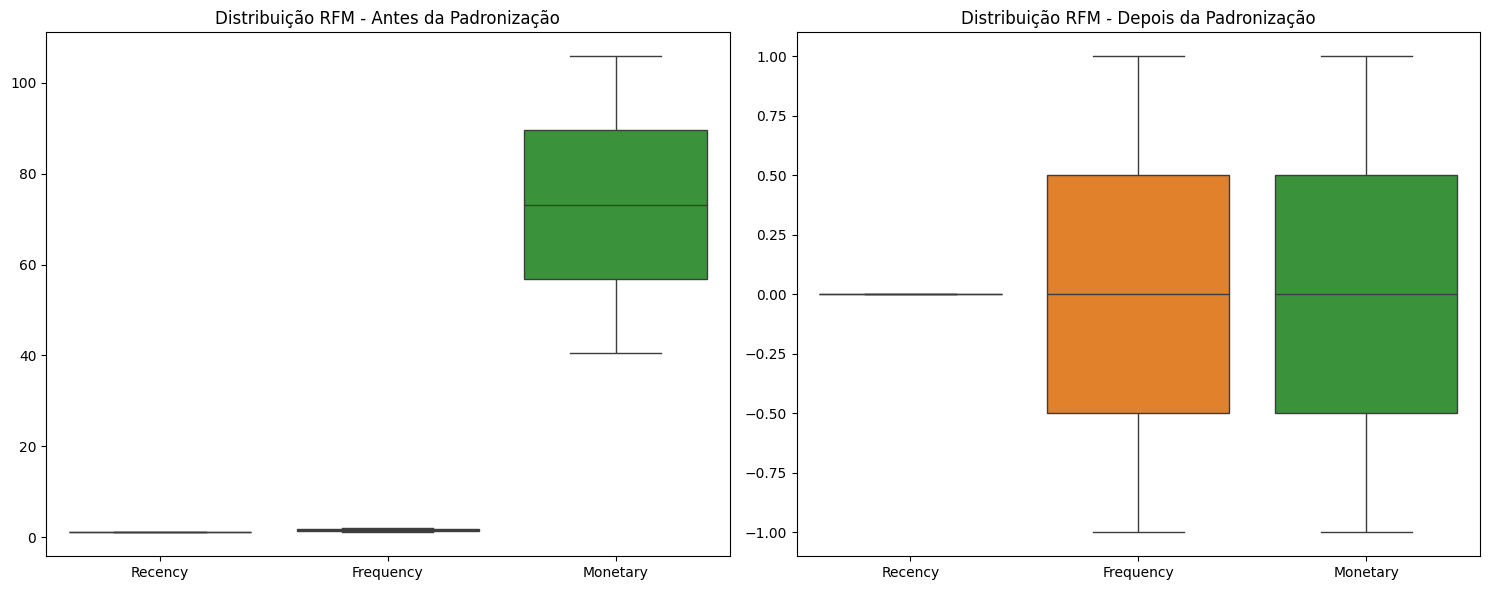

In [10]:
# Criando a figura e os eixos para os plots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot dos dados originais
sns.boxplot(data=rfm, ax=axes[0])
axes[0].set_title('Distribuição RFM - Antes da Padronização')

# Boxplot dos dados padronizados
sns.boxplot(data=rfm_scaled_df, ax=axes[1])
axes[1].set_title('Distribuição RFM - Depois da Padronização')

plt.tight_layout()
plt.show()

### Exercício Prático 3: Normalização Manual

Dado um array NumPy `dados = np.array([[10], [20], [30], [40], [50]])`, calcule a média e o desvio padrão. Em seguida, aplique a fórmula do `StandardScaler` manualmente a cada elemento do array para padronizá-lo.

In [ ]:
# --- SEU CÓDIGO AQUI ---
dados = np.array([[10], [20], [30], [40], [50]])

# 1. Calcular média e desvio padrão


# 2. Aplicar a fórmula de padronização


## Seção 5: Encontrando os Grupos: Clusterização com K-Means

### 5.1. Como o K-Means Funciona? Uma Explicação Intuitiva

O K-Means é um dos algoritmos de clusterização mais populares. O processo pode ser entendido em alguns passos iterativos:

1.  **Escolha de `k`:** Define-se o número de clusters (`k`).
2.  **Inicialização:** O algoritmo posiciona aleatoriamente `k` **centróides** (centros dos clusters).
3.  **Atribuição:** Cada ponto de dado é atribuído ao cluster do centróide mais próximo.
4.  **Atualização:** A posição de cada centróide é recalculada como a média de todos os pontos atribuídos a ele.
5.  **Repetição:** Os passos 3 e 4 são repetidos até que os centróides parem de se mover significativamente (convergência).

O objetivo é minimizar a **Inércia** (*Within-Cluster Sum of Squares* - WCSS), que é a soma das distâncias ao quadrado de cada ponto ao seu centróide.

### 5.2. Determinando o Número de Clusters (k) com o Método do Cotovelo (Elbow Method)

A maior desvantagem do K-Means é que precisamos especificar `k` antecipadamente. O **Método do Cotovelo** é uma heurística visual que nos ajuda a tomar essa decisão. Executamos o K-Means para vários valores de `k` e plotamos a inércia (WCSS) para cada um. O ponto onde a taxa de diminuição da inércia abranda drasticamente, formando um "cotovelo", é um bom candidato para o `k` ótimo.

In [11]:
from sklearn.cluster import KMeans

# Usaremos 'rfm_scaled', o array NumPy com os dados padronizados
wcss = []
range_k = range(1, 11)

for i in range_k:
    # n_init='auto' é o padrão em versões mais recentes do scikit-learn
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_) # .inertia_ armazena o WCSS

# Plotando o gráfico do cotovelo
plt.figure(figsize=(10, 6))
plt.plot(range_k, wcss, marker='o', linestyle='--')
plt.title('Método do Cotovelo (Elbow Method)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('WCSS (Inércia)')
plt.xticks(range_k)
plt.grid(True)
plt.show()

ValueError: n_samples=2 should be >= n_clusters=3.



No gráfico de exemplo acima, o "cotovelo" parece estar em `k=3` ou `k=4`. Após `k=4`, a curva se achata, indicando que adicionar mais clusters não reduz a inércia de forma tão significativa. Para este workshop, escolheremos `k=4`.

### 5.3. Treinando o Modelo K-Means

Com o número de clusters definido, podemos treinar nosso modelo final. É importante definir um `random_state` para garantir que os resultados sejam **reprodutíveis**.

In [12]:
# Treinando o modelo final com k=4
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)

# Ajustando o modelo aos dados e prevendo os clusters para cada cliente
# .fit_predict() é um atalho para .fit() seguido de .predict()
clusters = kmeans.fit_predict(rfm_scaled)

# Adicionando a coluna de clusters ao nosso dataframe RFM original (não padronizado)
rfm['Cluster'] = clusters

print("Tabela RFM com a coluna de Cluster:")
print(rfm.head())

ValueError: n_samples=2 should be >= n_clusters=4.

### Exercício Prático 4: Experimentando com `k`

Execute o código do Método do Cotovelo. Em seguida, treine dois modelos K-Means distintos: um com `k=3` e outro com `k=5`. Imprima o atributo `.inertia_` de cada um. Qual modelo tem a menor inércia e por que isso acontece?

In [ ]:
# --- SEU CÓDIGO AQUI ---

# Modelo com k=3


# Modelo com k=5



## Seção 6: Dando Sentido aos Dados: Análise e Interpretação dos Segmentos

### 6.1. Análise dos Centróides: O Coração de Cada Cluster

O resultado do K-Means — uma série de rótulos numéricos (0, 1, 2, 3) — é matematicamente correto, mas comercialmente inútil por si só. O verdadeiro valor da segmentação emerge da **interpretação**: o que cada um desses grupos de clientes representa em termos de negócio? A análise dos centróides é a ponte que conecta o resultado do algoritmo à inteligência de negócio.

Os centróides retornados pelo modelo (`kmeans.cluster_centers_`) estão na escala padronizada. Para que façam sentido, precisamos reverter a padronização e trazê-los de volta para suas escalas originais usando o método `.inverse_transform()` do `scaler`.

In [ ]:
# Obtendo os centróides dos clusters (ainda na escala padronizada)
centroids_scaled = kmeans.cluster_centers_

# Revertendo a padronização para a escala original
centroids_original = scaler.inverse_transform(centroids_scaled)

# Criando um DataFrame para facilitar a análise dos centróides
centroids_df = pd.DataFrame(centroids_original, columns=['Recency', 'Frequency', 'Monetary'])

print("Centróides dos Clusters (Valores Originais):")
print(centroids_df)

### 6.2. Criando Personas para Cada Cluster

Com a tabela de centróides em mãos, podemos analisar cada cluster e dar-lhe um nome ou "persona" que descreva seu comportamento. O processo envolve comparar os valores de R, F e M de cada cluster com os demais.

**Análise (exemplo baseado em uma execução típica):**

* **Cluster X (Recência baixa, Frequência alta, Monetário alto):** Estes são os melhores clientes. **Nome Sugerido: Clientes Campeões**.
* **Cluster Y (Recência alta, Frequência baixa, Monetário baixo):** Clientes que não compram há muito tempo. **Nome Sugerido: Clientes Adormecidos/Perdidos**.
* **Cluster Z (Valores intermediários):** Clientes que precisam de um incentivo para voltar. **Nome Sugerido: Clientes em Risco**.
* **Cluster W (Recência baixa, Frequência baixa, Monetário alto):** Compraram recentemente e gastaram muito, mas ainda não são frequentes. **Nome Sugerido: Novos Clientes de Alto Valor**.

Vamos mapear esses nomes para os nossos clusters.

In [ ]:
# Vamos analisar os centróides e atribuir nomes
# Esta etapa é manual e interpretativa. Os nomes podem variar.
# Exemplo de lógica para nomear clusters (pode precisar de ajuste dependendo dos resultados):
cluster_names = {
    0: 'Clientes em Risco',
    1: 'Clientes Campeões',
    2: 'Clientes Adormecidos',
    3: 'Novos Clientes de Alto Valor'
}

# Mapeando os nomes para a coluna de cluster no dataframe rfm
rfm['Segment'] = rfm['Cluster'].map(cluster_names)

print("Contagem de clientes por segmento:")
print(rfm['Segment'].value_counts())

print("\nAnálise dos segmentos (médias RFM por segmento):")
print(rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean())

### 6.3. Visualizando os Segmentos: O Snake Plot

O **Snake Plot** é uma excelente ferramenta para visualizar e comparar as características dos diferentes clusters. É um gráfico de linhas onde cada linha representa um cluster, o eixo X mostra as métricas RFM e o eixo Y mostra o valor médio (padronizado) para cada métrica.

In [ ]:
# Criando um DataFrame com os centróides padronizados para o plot
centroids_scaled_df = pd.DataFrame(centroids_scaled, columns=['Recency', 'Frequency', 'Monetary'])
centroids_scaled_df['Segment'] = list(cluster_names.values()) # Adicionando os nomes dos segmentos

# "Derretendo" o DataFrame para o formato longo, ideal para o seaborn
datamart_melt = pd.melt(centroids_scaled_df,
                        id_vars='Segment',
                        value_vars=['Recency', 'Frequency', 'Monetary'],
                        var_name='Metric',
                        value_name='Value')

# Criando o Snake Plot
plt.figure(figsize=(12, 7))
sns.lineplot(data=datamart_melt, x='Metric', y='Value', hue='Segment', palette='viridis', marker='o')
plt.title('Snake Plot dos Segmentos de Clientes')
plt.xlabel('Métricas RFM')
plt.ylabel('Valor Padronizado (Centróide)')
plt.legend(title='Segmento')
plt.grid(True)
# Adicionando uma linha horizontal em y=0 para representar a média da população
plt.axhline(0, color='black', linestyle='--')
plt.show()



O Snake Plot confirma visualmente nossa análise dos centróides, tornando a comunicação dos resultados para stakeholders (como a equipe de marketing) muito mais clara e impactante.

## Seção 7: Conclusão e Próximos Passos

### 7.1. Resumo do Projeto

Nesta aula, realizamos uma jornada completa de um projeto de ciência de dados aplicado a um problema real de negócio. Partimos de um dataset bruto e, através de um processo estruturado de limpeza de dados, engenharia de features (RFM), pré-processamento (padronização) e modelagem de machine learning (K-Means), chegamos a uma segmentação de clientes clara, acionável e baseada em dados. O resultado final não são apenas números, mas sim personas de clientes com comportamentos distintos, para os quais estratégias de marketing personalizadas podem ser desenvolvidas.

### 7.2. Aplicações no Mundo Real para Desenvolvedores Web

O conhecimento adquirido neste workshop transcende a análise de dados e pode ser diretamente aplicado por desenvolvedores web para criar sistemas mais inteligentes e personalizados:

* **Integração com Sistemas de CRM:** Os segmentos de clientes gerados podem ser exportados e usados para "etiquetar" (tag) clientes em sistemas de CRM (Customer Relationship Management).
* **Personalização de Conteúdo em Tempo Real:** Um sistema web pode consultar o segmento de um cliente logado para personalizar dinamicamente a experiência (ex: banners, cupons).
* **Criação de uma API de Segmentação:** O modelo K-Means treinado e o objeto `StandardScaler` podem ser salvos (serializados com `pickle` ou `joblib`) e encapsulados em uma API. Outros microsserviços poderiam então enviar os dados RFM de um cliente para esta API e receber de volta o seu segmento em tempo real.

## Seção 8: Desafio Final: Segmentando Clientes no E-commerce Brasileiro

### 8.1. Apresentação do Novo Dataset: "Brazilian E-Commerce Public Dataset by Olist"

Para consolidar todo o conhecimento adquirido, o desafio final consiste em aplicar a mesma metodologia a um dataset diferente e mais complexo: o "Brazilian E-Commerce Public Dataset by Olist", disponível no Kaggle. Este dataset contém informações de aproximadamente 100.000 pedidos realizados no Brasil. O principal desafio aqui é que a informação está distribuída em várias tabelas que precisam ser unidas.

### 8.2. O Roteiro do Desafio

O objetivo é repetir todo o processo de segmentação de clientes.

1.  **Carregar os Dados:** Carregue os arquivos `olist_customers_dataset.csv`, `olist_orders_dataset.csv` e `olist_order_items_dataset.csv`.
2.  **Unir as Tabelas (Join):** Use `pd.merge` para criar um único dataframe que contenha, para cada item de pedido, as informações do cliente e da data da compra.
3.  **Construir o Modelo RFM:**
    * **Recência:** Use `order_purchase_timestamp`.
    * **Frequência:** Conte os `order_id` únicos por `customer_unique_id`.
    * **Valor Monetário:** Some a coluna `price`.
    * Execute todo o pipeline: limpeza, cálculo RFM, padronização, Método do Cotovelo e K-Means.
4.  **Analisar e Apresentar os Resultados:**
    * Analise os centróides, crie personas e gere um Snake Plot.
    * **Bônus:** Compare os perfis de clientes do e-commerce brasileiro com os do varejista do Reino Unido.:

In [ ]:
# Código de exemplo para iniciar o desafio
print("Iniciando o Desafio Final - Dataset Olist")

# 1. Carregar os dados (substitua com os caminhos corretos)
try:
    customers = pd.read_csv('olist_customers_dataset.csv')
    orders = pd.read_csv('olist_orders_dataset.csv')
    order_items = pd.read_csv('olist_order_items_dataset.csv')

    # 2. Unir as tabelas
    df_olist = orders.merge(customers, on='customer_id')
    df_olist = df_olist.merge(order_items, on='order_id')

    print("\nDataset Olist unido com sucesso. Formato:", df_olist.shape)
    print(df_olist.head())

    # A partir daqui, você pode aplicar o pipeline RFM aprendido na aula.
    # Lembre-se de converter a data, criar a snapshot_date, agrupar por 'customer_unique_id', etc.

except FileNotFoundError:
    print("\nArquivos do dataset Olist não encontrados. Pule o desafio ou baixe os arquivos do Kaggle.")
    print("Link: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce")